In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df= pd.read_csv('sales_data_sample.csv')
print(df.head())
print(df.info())
print(df.describe())
ndf=df.dropna()

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye           NaN

In [9]:
ndf['ORDERDATE']=pd.to_datetime(ndf['ORDERDATE'])
print(ndf.info())

<class 'pandas.DataFrame'>
Index: 147 entries, 10 to 2791
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       147 non-null    int64         
 1   QUANTITYORDERED   147 non-null    int64         
 2   PRICEEACH         147 non-null    float64       
 3   ORDERLINENUMBER   147 non-null    int64         
 4   SALES             147 non-null    float64       
 5   ORDERDATE         147 non-null    datetime64[us]
 6   STATUS            147 non-null    str           
 7   QTR_ID            147 non-null    int64         
 8   MONTH_ID          147 non-null    int64         
 9   YEAR_ID           147 non-null    int64         
 10  PRODUCTLINE       147 non-null    str           
 11  MSRP              147 non-null    int64         
 12  PRODUCTCODE       147 non-null    str           
 13  CUSTOMERNAME      147 non-null    str           
 14  PHONE             147 non-null    str   

In [10]:
daily_sales = ndf.groupby('ORDERDATE')['SALES'].sum()
monthly_sales = ndf.groupby(ndf['ORDERDATE'].dt.to_period('M'))['SALES'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

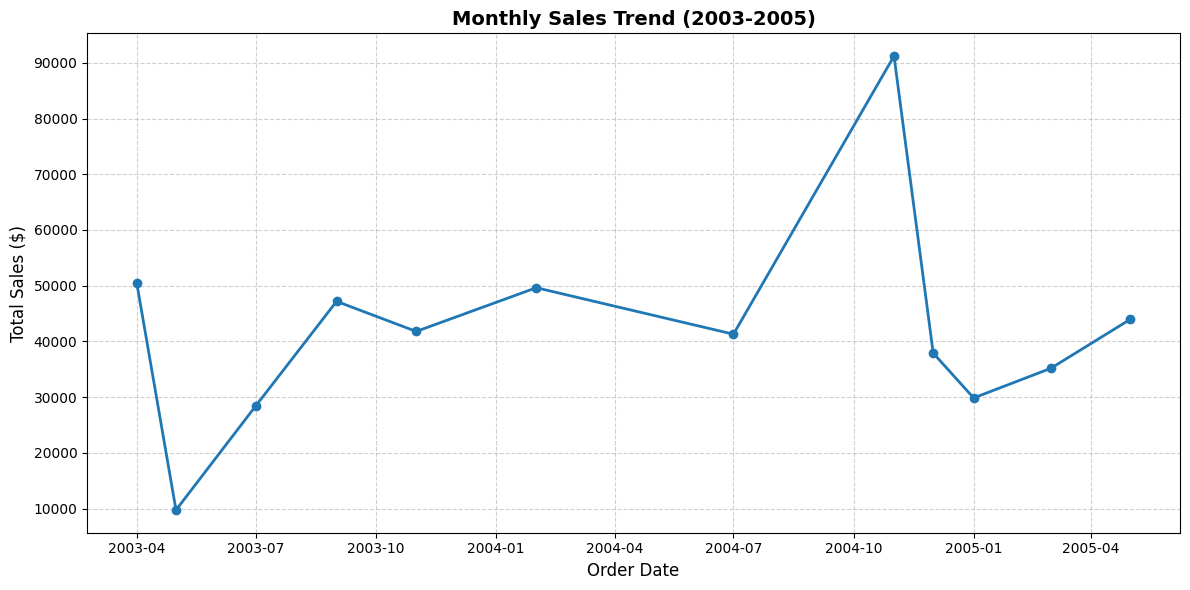

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='tab:blue', linewidth=2)
plt.title('Monthly Sales Trend (2003-2005)', fontsize=14, fontweight='bold')
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')

#The monthly sales trend analysis reveals noticeable fluctuations in total sales between 2003 and 2005. Sales show a significant peak during late 2004, indicating a period of high demand or successful sales activity. This peak is followed by a decline in early 2005, suggesting possible seasonality or market slowdown. Overall, the trend highlights that sales performance is not uniform across months and may be influenced by seasonal or business-specific factors.

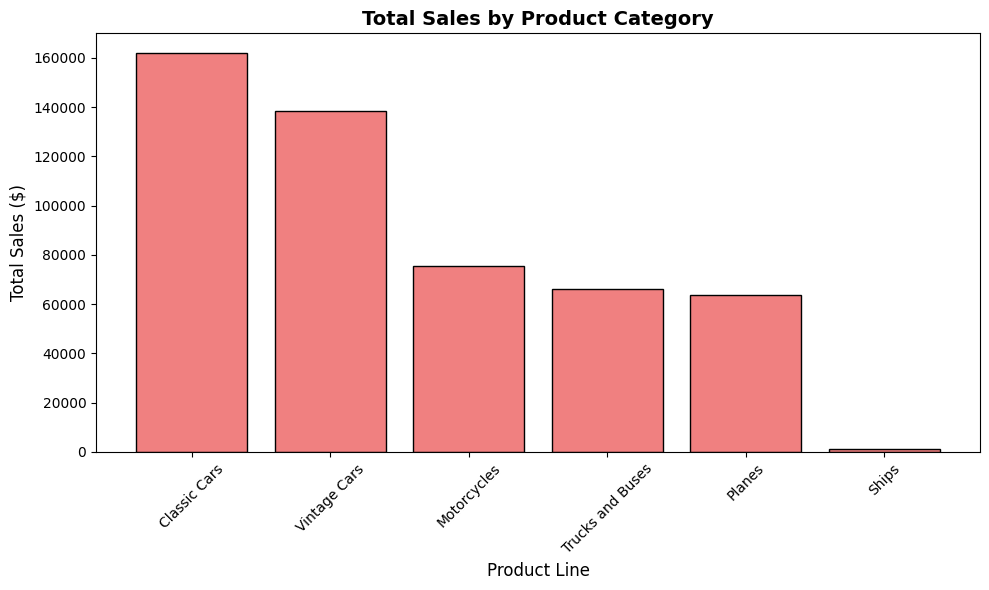

In [12]:
product_sales = ndf.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(product_sales.index, product_sales.values, color='lightcoral', edgecolor='black')
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_product_line.png')

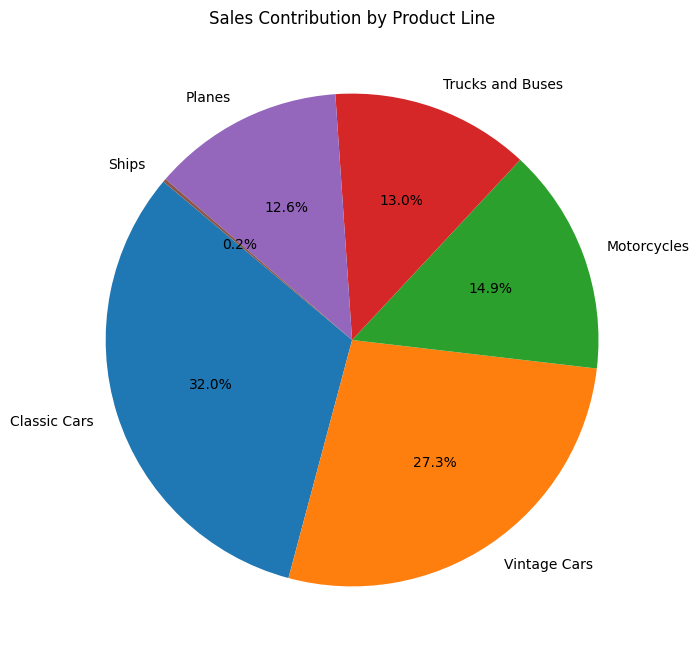

In [15]:
plt.figure(figsize=(8,8))
plt.pie(
    product_sales.values,
    labels=product_sales.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Sales Contribution by Product Line")
plt.savefig("sales_by_productline_pie.png")
plt.show()


In [16]:
ndf.to_csv('cleaned_sales_data_sample.csv')